In [158]:
#dataframes
import pandas as pd

#speedup
import multiprocessing as mp

#suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.TimeSeries = pd.Series 

#math
import numpy as np
import sys
sys.path.append("../")
import odor_stat_calculations as osc
from dataclasses import dataclass
from typing import Tuple
from itertools import groupby
from operator import itemgetter
from scipy.spatial.distance import cdist
from scipy.ndimage import gaussian_filter

#plots
import pylab as plt
import matplotlib.pyplot as plt
from matplotlib.path import Path
import matplotlib.patches as patches
import matplotlib.transforms as transforms

from figurefirst import mpl_functions
import figurefirst
from mpl_toolkits.axes_grid1 import make_axes_locatable # for colorbar
import seaborn as sns
sns.set_style("whitegrid")
import figurefirst as fifi

#misc
import time
np.set_printoptions(suppress=True)
import fly_plot_lib.plot as fpl
FS=7


In [6]:
def load():
    layout = fifi.svg_to_axes.FigureLayout('../svgs/different_time_series.svg', autogenlayers=True, make_mplfigures=True, hide_layers=[])
    return layout
df_test = pd.read_hdf('../data/hws/hws.h5')
dfres=pd.read_hdf("../data/algorithm/WindyMASigned.h5")
# dirname = '../../data/simulator/figure/Figure_hws/'
hmap_data = np.load("../data/hws/hmap.npz")
    
fitted_p_heatmap=hmap_data['fitted_heatmap']
xedges=hmap_data['xedges']
yedges=hmap_data['yedges']

index = osc.get_index(dfres.odor,4.5)
whiff_initiation_points = [sub[0] for sub in index]
dfres['whiff_flag'] = 0

# fdf=pd.read_hdf("../data/hws/whiff.h5")
# Set 1 for the specified indices in the 'whiff_flag' column
dfres.iloc[whiff_initiation_points, dfres.columns.get_loc('whiff_flag')] = 1

dfres['distance_along_streakline']=dfres.distance_along_streakline*dfres.xsign
dfres['nearest_from_streakline']=dfres.nearest_from_streakline*dfres.ysign

test_data = df_test[(df_test['time'] >= 337) & (df_test['time'] <= 339)]
test_data.reset_index(inplace=True, drop=True)

In [31]:
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase
def vector_cbar(ax, cmap='Blues', vmin=4.5, vmax=10.0, ticks=(5,10),
                nsteps=256, label=r"wc$_F$, a.u", fs=8,
                spine_offset_pts=2, tick_len=1.5, lw=0.5, pad=1):
    cmap = plt.get_cmap(cmap)
    norm = Normalize(vmin=vmin, vmax=vmax)

    # bar geometry in data coords
    y = np.linspace(vmin, vmax, nsteps+1)
    x0, x1 = 0.0, 1.0  # thin vertical bar filling axis width
    for i in range(nsteps):
        yi0, yi1 = y[i], y[i+1]
        color = cmap(norm((yi0+yi1)/2.0))
        ax.add_patch(plt.Rectangle((x0, yi0), x1-x0, yi1-yi0,
                                   facecolor=color, edgecolor='none'))

    # framing, ticks, labels
    ax.set_xlim(x0, x1)
    ax.set_ylim(vmin, vmax)
    for side in ('left','top','bottom'):
        ax.spines[side].set_visible(False)
    ax.spines['right'].set_linewidth(lw)
    ax.spines['right'].set_position(('outward', spine_offset_pts))
    ax.spines['right'].set_color('black')

    ax.set_yticks(list(ticks))
    ax.set_yticklabels([str(t) for t in ticks])
    ax.tick_params(axis='y', which='both', right=True, left=False,
                   labelright=True, labelleft=False,
                   length=tick_len, width=lw, pad=pad)

    ax.set_xticks([])  # none on x for a vertical bar
    ax.set_ylabel(label, rotation=90, labelpad=-20)
    for item in (ax.yaxis.get_ticklabels() + [ax.yaxis.label]):
        item.set_fontsize(fs)

def nice_cbar(ax, cmap='Blues', vmin=4.5, vmax=10.0, ticks=(5,10),
              label=r"wc$_F$, a.u", fs=8,
              spine_offset_pts=2, tick_len=1.5, lw=0.5, pad=1):
    # draw the colorbar into the axis you already placed in the layout
    norm = Normalize(vmin=vmin, vmax=vmax)
    ColorbarBase(ax, cmap=plt.get_cmap(cmap), norm=norm, orientation='vertical', ticks=ticks)

    # make it look like your style (right spine only, nudged outward)
    for side in ('left','top','bottom'):
        ax.spines[side].set_visible(False)
    ax.spines['right'].set_linewidth(lw)
    ax.spines['right'].set_position(('outward', spine_offset_pts))
    ax.spines['right'].set_color('black')

    # ticks on the right, short ticks, tight padding
    ax.tick_params(axis='y', which='both', right=True, left=False,
                   labelright=True, labelleft=False,
                   length=tick_len, width=lw, pad=pad)

    # set exact tick labels if you want to override formatting
    ax.set_yticks(list(ticks))
    ax.set_yticklabels([str(t) for t in ticks])

    # label
    ax.set_ylabel(label, rotation=90, labelpad=-20)
    # keep it vector-friendly in layered figures
    ax.set_rasterization_zorder(-20)
    # match your font size helper
    for item in (ax.yaxis.get_ticklabels() + [ax.yaxis.label]):
        item.set_fontsize(fs)

In [18]:
def avg_distance(df,index,dat): #input ; location ; storage
    i = 0
    distance_along_streakline = []
    nearest_from_streakline = []
    while i<len(index):
        distance_along_streakline.append(np.mean(df.distance_along_streakline[index[i]]))
        nearest_from_streakline.append(np.mean(df.nearest_from_streakline[index[i]]))
        i+=1
    dat['avg_distance_along_streakline']= distance_along_streakline
    dat['avg_nearest_from_streakline'] = nearest_from_streakline

def get_index_nowhiff(data, th):
    idx = [i for i, value in enumerate(data) if value < th]
    index = [list(map(itemgetter(1), g)) for k, g in groupby(enumerate(idx), lambda ix: ix[0] - ix[1])]
    return index

def avg_distance_nowhiff(df, idx, dat):
    distance_along_streakline = []
    nearest_from_streakline = []
    for indices in idx:
        if indices:  # Check if indices list is not empty
            distance_along_streakline.append(np.mean(df['distance_along_streakline'].iloc[indices]))
            nearest_from_streakline.append(np.mean(df['nearest_from_streakline'].iloc[indices]))
        else:
            distance_along_streakline.append(np.nan)
            nearest_from_streakline.append(np.nan)

    dat['avg_distance_along_streakline'] = distance_along_streakline
    dat['avg_nearest_from_streakline'] = nearest_from_streakline

def wc_wsd_nowhiff(df, idx, dat):
    wc_nowhiff = []
    std_dev_nowhiff = []
    for indices in idx:
        if indices:  # Check if indices list is not empty
            wc_nowhiff.append(np.mean(df['odor'].iloc[indices]))
            std_dev_nowhiff.append(np.std(df['odor'].iloc[indices]))
        else:
            wc_nowhiff.append(np.nan)
            std_dev_nowhiff.append(np.nan)

    dat['wc_nowhiff'] = wc_nowhiff
    dat['wsd_nowhiff'] = std_dev_nowhiff

def cal_stat(df,idx,df2):
    osc.avg_distance(df,idx,df2)
    osc.mean_conc(df,idx,df2)
    osc.whiff_blank_duration(df,idx,df2)
    osc.std_whiff(df,idx,df2)
    osc.mean_avg(df,idx,df2)
    osc.encounter_frequency(df,idx,df2,1,2)
    osc.mean_t(df,idx,df2)

th = 4.5
np.seterr(divide='ignore')
index = osc.get_index(dfres.odor,th)
index_nowhiff = get_index_nowhiff(dfres.odor,th)
fdf = pd.DataFrame()
fdf_nowhiff=pd.DataFrame()

cal_stat(dfres,index,fdf)
avg_distance(dfres, index, fdf)
wc_wsd_nowhiff(dfres, index_nowhiff,fdf_nowhiff)
avg_distance_nowhiff(dfres,index_nowhiff,fdf_nowhiff)

In [ ]:
def logit(x, lower=0.0, upper=10.0, eps=1e-8):
    """
    Convert x in [lower, upper] to an unbounded real z in (-inf, +inf).
    We clamp x slightly to avoid taking log(0).
    """
    x_clamped = np.clip(x, lower + eps, upper - eps)
    scale = upper - lower
    ratio = (x_clamped - lower) / scale
    return np.log(ratio / (1 - ratio))

def inv_logit(z, lower=0.0, upper=10.0):
    """
    Convert an unbounded real z in (-inf, +inf) back to [lower, upper].
    """
    scale = upper - lower
    return lower + scale / (1.0 + np.exp(-z))

class OdorStateManager:
    def __init__(self, config, whiff_intermittency):
        # Start odor at base level, but store internally in z-space
        z_init = logit(config.base_odor_level, 0, 10)
        self.z_current = z_init
        self.z_prev    = z_init

        # For reference/tracking we also keep actual odor in [0..10]
        # (initialized to the base_odor_level).
        self.current_concentration = config.base_odor_level
        self.prev_concentration    = config.base_odor_level

        # For other state logic
        self.recent_history        = [0] * 1000
        self.recent_concentrations = [config.base_odor_level] * 10
        self.recent_intermittencies = list(np.random.choice(whiff_intermittency, 5))
        self.in_whiff_state = False
        self.state_duration = 0

@dataclass
class OdorConfig:
    rows_per_second: int = 200
    base_odor_level: float = 0.6
    distance_threshold: float = 3
    # AR(2) base coefficients
    ar1: float = 0.98
    ar2: float = -0.02
    warmup_steps: int = 1000
    low_threshold: float = 0.05
    history_length: int = 7
    # Transition matrix for whiff states
    transition_matrix: np.ndarray = np.array([[0.15, 0.85],
                                              [0.15, 0.85]])

class ParallelOdorPredictor:
    def __init__(self, df_test: pd.DataFrame, fdf: pd.DataFrame, fdf_nowhiff: pd.DataFrame):
        self.config = OdorConfig()
        self.df_test = df_test
        self.fdf = fdf
        self.fdf_nowhiff = fdf_nowhiff
        self.setup_data()

    def setup_data(self):
        distance_bins = np.arange(0, 51, 5)  # [0, 15, 30, 45, 60]
        nearest_bins = np.arange(-15, 16, 5)  
        
        self.bin_data_dict = {}
        
        for i in range(len(distance_bins)-1):
            for j in range(len(nearest_bins)-1):
                start_dist, end_dist = distance_bins[i], distance_bins[i+1]
                start_near, end_near = nearest_bins[j], nearest_bins[j+1]
                
                bin_data = self.fdf[
                    (self.fdf['avg_distance_along_streakline'] >= start_dist) & 
                    (self.fdf['avg_distance_along_streakline'] < end_dist) &
                    (self.fdf['avg_nearest_from_streakline'] >= start_near) &
                    (self.fdf['avg_nearest_from_streakline'] < end_near)
                ]['odor_intermittency'].dropna().values
                
                self.bin_data_dict[(start_dist, end_dist, start_near, end_near)] = bin_data
    @staticmethod
    def calculate_distance_from_source(x: float, y: float) -> float:
        """Euclidean distance from source (assume (0,0)) to point (x,y)."""
        return np.sqrt(x**2 + y**2)

    def generate_intermittency(self, distance_along: float, distance_from: float,
                           state: OdorStateManager, default: float = 0.05) -> float:
        last_values = np.array(state.recent_intermittencies[-self.config.history_length:])
        low_frequency = np.mean(last_values < self.config.low_threshold)
        
        for (sd, ed, sn, en), values in self.bin_data_dict.items():
            if (sd <= distance_along < ed) and (sn <= distance_from < en):
                if len(values) > 0:
                    if low_frequency > 0.5:
                        median_val = np.median(values)
                        subset = values[values < median_val]
                        if len(subset) > 0:
                            intermittency = np.random.choice(subset)
                        else:
                            intermittency = np.random.choice(values)
                    else:
                        intermittency = np.random.choice(values)
                    return np.clip(intermittency, np.min(values), np.max(values))
        return default

    # ------------------------------------
    # 3c) Update whiff posterior
    # ------------------------------------
    def update_whiff_posterior(self, prior_prob: float, state: OdorStateManager) -> float:
        """
        Example function to incorporate a Markov chain / state transition
        plus some heuristics about recent whiffs, etc.
        """
        whiff_state = 1 if state.in_whiff_state else 0
        num_recent_whiffs = sum(state.recent_history[-20:])
        
        # Time since last whiff
        time_since_whiff = 0
        for i in range(len(state.recent_history)-1, -1, -1):
            if state.recent_history[i]:
                break
            time_since_whiff += 1
        scaler=0.25
        time_since_last_whiff = min(1.5, time_since_whiff ) if time_since_whiff > 50 else 1.0
        recent_whiff_memory = (1 + (num_recent_whiffs ) * scaler) * time_since_last_whiff
                
        posterior = ((prior_prob * scaler)
                     * self.config.transition_matrix[whiff_state][1]
                     * recent_whiff_memory)
                    #  * concentration_factor)
        
        return posterior
    
    def update_ar2_concentration(self, current: float, prev: float, target: float, 
                               noise_scale: float) -> float:
        noise = noise_scale * (np.random.randn() - 0.5) * 0.5
        x_next = (0.85 * (self.config.ar1 * (current - target) + 
                 self.config.ar2 * (prev - target)) + target + noise)
        return x_next

    def update_ar2_in_zspace(self, z_current: float, z_prev: float,
                             z_target: float, distance: float,
                             base_noise_scale: float = 0.1,
                             jump_prob: float = 0.05) -> float:
        """
        Perform an AR(2)-like update, but in 'z' (logit) space, so that
        when we transform back via inv_logit, the odor is guaranteed in [0,10].
        
        distance is used to modulate noise or AR coefficients if desired.
        """
        # Distance factor to damp or intensify fluctuations
        distance_factor = np.exp(-distance / 50.0)  # decays with distance

        # Possibly adjust AR(1), AR(2), etc. coefficients
        ar1_local = self.config.ar1 * (1 + 0.1 * distance_factor)
        ar2_local = self.config.ar2 * (1 - 0.1 * distance_factor)
        
        # Base random noise
        noise = base_noise_scale * (1 + 2 * distance_factor) * np.random.randn()
        
        # Optional “jumps”
        if np.random.rand() < jump_prob:
            jump_size = np.random.uniform(-1, 1) * base_noise_scale * 3
            noise += jump_size

        # AR(2) update in unbounded space
        z_next = 0.85 * (ar1_local * (z_current - z_target)
                         + ar2_local * (z_prev - z_target)) \
                 + z_target + noise

        return z_next

    # ------------------------------------
    # 3e) Main loop over data
    # ------------------------------------
    def process_segment(self, start_idx: int, end_idx: int,
                        state: OdorStateManager) -> Tuple[np.ndarray, np.ndarray]:
        segment = self.df_test.iloc[start_idx:end_idx]

        concentrations = np.full(len(segment), self.config.base_odor_level)
        predictions = np.zeros(len(segment), dtype=int)

        test_locations    = segment[['distance_along_streakline','nearest_from_streakline']].values
        whiff_locations   = self.fdf[['avg_distance_along_streakline','avg_nearest_from_streakline']].values
        nowhiff_locations = self.fdf_nowhiff[['avg_distance_along_streakline','avg_nearest_from_streakline']].values

        # Distances from (0,0) if you want to scale noise by how far we are
        distances_from_source = np.array([
            self.calculate_distance_from_source(x, y) 
            for x, y in test_locations
        ])
        distances = cdist(test_locations, whiff_locations)
        distances_nowhiff = cdist(test_locations, nowhiff_locations)

        i = 0
        while i < len(segment):
            # Skip warmup to let the AR state stabilize
            if start_idx + i < self.config.warmup_steps:
                i += 1
                continue

            prior_prob = segment.spatial_prob.iloc[i]
            posterior = self.update_whiff_posterior(prior_prob, state)

            # State transitions for whiff on/off
            if state.in_whiff_state:
                state.state_duration += 1
                # After min_duration, we might exit whiff with some prob
                min_duration = 0.1 * self.config.rows_per_second
                if state.state_duration > min_duration:
                    continue_prob = 0.5 * prior_prob
                    state.in_whiff_state = (np.random.rand() < continue_prob)
            else:
                # Chance to enter whiff
                # transition_prob = posterior * (1 + max(0, concentration_factor) * 0.3)
                transition_prob = posterior
                state.in_whiff_state = (np.random.rand() < transition_prob * 0.5)
                if state.in_whiff_state:
                    state.state_duration = 0

            # If whiff and close enough, generate whiff concentrations
            if state.in_whiff_state and (np.min(distances[i]) <= self.config.distance_threshold):
                nearest_idx = np.argmin(distances[i])
                mean_concentration = self.fdf.mean_concentration.values[nearest_idx]
                std_dev_whiff      = self.fdf.std_whiff.values[nearest_idx]
                duration           = int(self.fdf.length_of_encounter.values[nearest_idx] *
                                         self.config.rows_per_second)
                rows_to_fill = min(duration, len(segment) - i)

                # Convert the whiff's mean concentration to z_target
                z_target = logit(mean_concentration, 0, 10)

                for j in range(rows_to_fill):
                    dist_here = distances_from_source[i + j] if (i+j) < len(distances_from_source) else 0
                    # AR(2) update in z, then invert to odor
                    z_next = self.update_ar2_in_zspace(
                        state.z_current, state.z_prev, z_target,
                        distance=dist_here,
                        base_noise_scale=0.4 * std_dev_whiff,
                        jump_prob=0.1
                    )
                    odor_next = inv_logit(z_next, 0, 10)

                    # Update state
                    state.z_prev = state.z_current
                    state.z_current = z_next
                    state.prev_concentration = state.current_concentration
                    state.current_concentration = odor_next

                    concentrations[i+j] = odor_next
                    predictions[i+j]    = 1

                    # Update rolling histories
                    state.recent_concentrations.append(odor_next)
                    state.recent_concentrations.pop(0)
                    state.recent_history.append(1)
                    state.recent_history.pop(0)

                i += rows_to_fill

                dist_along = segment.distance_along_streakline.iloc[i-1]
                dist_from = segment.nearest_from_streakline.iloc[i-1]
                intermittency = self.generate_intermittency(dist_along, dist_from, state)
                state.recent_intermittencies.append(intermittency)
                state.recent_intermittencies.pop(0)

                # Convert intermittency in seconds to # of rows
                intermittency_duration = int(intermittency * self.config.rows_per_second * 0.9)
                i += intermittency_duration

            else:
                # No-whiff update
                nearest_idx = np.argmin(distances_nowhiff[i])
                no_whiff_mean = self.fdf_nowhiff.wc_nowhiff.values[nearest_idx]
                no_whiff_std = self.fdf_nowhiff.wsd_nowhiff.values[nearest_idx]
                
                new_concentration = self.update_ar2_concentration(
                    state.current_concentration,
                    state.prev_concentration,
                    no_whiff_mean,
                    0.05 * no_whiff_std
                )
                new_concentration = np.clip(new_concentration, 0.6, 1.0)
                
                if i >= 10:
                    window_data = concentrations[i-10:i]
                    window_data = np.append(window_data, new_concentration)
                    window = np.ones(10)/10.0
                    new_concentration = np.convolve(window_data, window, mode='valid')[-1]
                
                state.prev_concentration = state.current_concentration
                state.current_concentration = new_concentration
                
                concentrations[i] = new_concentration
                state.recent_concentrations.append(new_concentration)
                state.recent_concentrations.pop(0)
                state.recent_history.append(0)
                state.recent_history.pop(0)
                
                i += 1

        return concentrations, predictions
    # ------------------------------------
    # 3f) High-level driver
    # ------------------------------------
    def predict(self) -> pd.DataFrame:
        # We split data into segments so that state carries over between segments
        segment_size = 2000
        total_segments = (
            len(self.df_test) // segment_size +
            (1 if len(self.df_test) % segment_size else 0)
        )

        all_concentrations = []
        all_predictions = []

        # Create the state manager
        state = OdorStateManager(self.config, self.fdf.odor_intermittency.values)

        for seg_idx in range(total_segments):
            start_idx = seg_idx * segment_size
            end_idx   = min((seg_idx + 1) * segment_size, len(self.df_test))

            concentrations, predictions = self.process_segment(start_idx, end_idx, state)
            all_concentrations.append(concentrations)
            all_predictions.append(predictions)

        # Concatenate results
        final_concentrations = np.concatenate(all_concentrations)
        final_predictions = np.concatenate(all_predictions)
        final_concentrations = gaussian_filter(final_concentrations, sigma=0.8)

        self.df_test.loc[:, 'predicted_odor'] = final_concentrations
        self.df_test.loc[:, 'whiff_predicted'] = final_predictions
        return self.df_test
    
        
def main():
    predictor = ParallelOdorPredictor(df_test, fdf, fdf_nowhiff)
    result_df = predictor.predict()
    return result_df



In [197]:
if __name__ == "__main__":
    test_result = main()
    df_test.loc[:, 'predicted_odor'] = test_result['predicted_odor']
    df_test.loc[:, 'whiff_predicted'] = test_result['whiff_predicted']
    
th=4.5
query1 = 'odor>'+ str(th)
new_test_df1 = df_test.query(query1)
new_test_df1.reset_index(inplace=True, drop=True)

query2 = 'predicted_odor>'+ str(th)
new_test_df2 = df_test.query(query2)
new_test_df2.reset_index(inplace=True, drop=True)

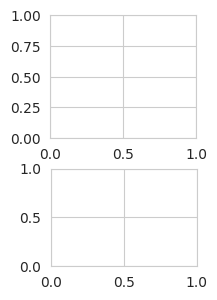

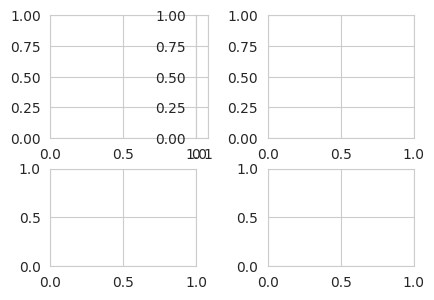

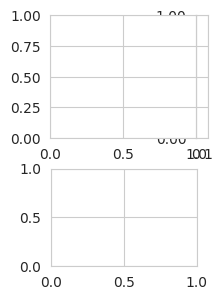

In [204]:
layout=load()

In [205]:
ax=layout.axes[('fig1','ax1')]
cax1 = ax.scatter(new_test_df1.distance_along_streakline, new_test_df1.nearest_from_streakline, c=new_test_df1.odor, s=1, 
                  edgecolors=None, cmap='Blues', alpha=0.2, vmin=5, vmax=10, rasterized=True)
ax.set_rasterization_zorder(-20)

ax.set_xlabel('x, m')
ax.xaxis.set_label_coords(0.5, -0.1)
ax.set_ylabel('y, m')
ax.yaxis.set_label_coords(-0.08, 0.5)

ax.ticklabel_format(useOffset=False)
ax.set_xlim(0,50)
ax.set_title('NWhiffs='+str(len(new_test_df1)))
ax.grid(False)
mpl_functions.adjust_spines(ax,['left','bottom'],
                           spine_locations={'left': 5, 'bottom': 6}, 
                           smart_bounds=True,
                           yticks=[-15,15],
                           xticks=[0,50],
                           linewidth=0.5)

figurefirst.mpl_functions.set_fontsize(ax, FS)
layout.append_figure_to_layer(layout.figures['fig1'], 'fig1', cleartarget=True)
layout.write_svg('../svgs/different_time_series.svg')

In [206]:
ax = layout.axes[('fig1', 'cbar1')]
ytic=[4.5,10]


# nice_cbar(ax=ax, colormap='Blues', orientation='vertical',ticks=ytic)
nice_cbar(ax, cmap='Blues', vmin=4.5, vmax=10.0, ticks=(4.5,10), fs=FS)
ax.set_rasterization_zorder(-20)
mpl_functions.adjust_spines(ax, ['right'], 
                                    smart_bounds=True,
                                    spine_locations={'right': 2}, 
                                    yticks=ytic,
                                    tick_length=1.5,
                                    linewidth=0.5)

ax.set_ylabel("wc$_{D}$, a.u",rotation=90, labelpad=-10)
ax.set_yticklabels(['4.5', '10'])
ax.tick_params(axis='y', pad=1) 
figurefirst.mpl_functions.set_fontsize(ax, FS)


layout.append_figure_to_layer(layout.figures['fig1'], 'fig1', cleartarget=True)
layout.write_svg('../svgs/different_time_series.svg')

In [207]:
ax=layout.axes[('fig1','ax2')]
ax.plot(df_test.time, df_test.odor, linewidth=1,c='#1764ab', rasterized=True)
ax.set_rasterization_zorder(-20)
# xlimTs=[138,143]
xlimTs=[350,360]
ax.set_xlabel('10 s')
ax.xaxis.set_label_coords(0.5, -0.15)
ax.set_ylabel('odor$_{D}$\na.u.')
ax.yaxis.set_label_coords(-0.1, 0.5)
ax.set_xlim(xlimTs)
ax.grid(False)
mpl_functions.adjust_spines(ax,['left','bottom'],
                           spine_locations={'left': 5, 'bottom': 6}, 
                           smart_bounds=True,
                           yticks=[0,10.5],
                           xticks=xlimTs,
                           linewidth=0.5)

figurefirst.mpl_functions.set_fontsize(ax, FS)
layout.append_figure_to_layer(layout.figures['fig1'], 'fig1', cleartarget=True)
layout.write_svg('../svgs/different_time_series.svg')

column 2

In [208]:
ax=layout.axes[('fig1','ax3')]
cax1 = ax.scatter(new_test_df2.distance_along_streakline, new_test_df2.nearest_from_streakline, c=new_test_df2.predicted_odor, s=1, 
                  edgecolors=None, cmap='Reds', alpha=0.2, vmin=5, vmax=10, rasterized=True)
ax.set_rasterization_zorder(-20)


ax.set_xlabel('x, m')
ax.xaxis.set_label_coords(0.5, -0.1)
ax.set_ylabel('y, m')
ax.yaxis.set_label_coords(-0.08, 0.5)
ax.set_title('NWhiffs='+str(len(new_test_df2)))
ax.ticklabel_format(useOffset=False)
ax.set_xlim(0,50)
ax.grid(False)
mpl_functions.adjust_spines(ax,['left', 'bottom'],
                           spine_locations={'left': 5, 'bottom': 6}, 
                           smart_bounds=True,
                           yticks=[-15,15],
                           xticks=[0,50],
                           linewidth=0.5)

figurefirst.mpl_functions.set_fontsize(ax, FS)
layout.append_figure_to_layer(layout.figures['fig1'], 'fig1', cleartarget=True)
layout.write_svg('../svgs/different_time_series.svg')

In [209]:
ax=layout.axes[('fig1','ax4')]
ax.plot(df_test.time, df_test.predicted_odor, linewidth=1,c='#bc141a', rasterized=True)
ax.set_rasterization_zorder(-20)
# xlimTs=[138,143]
xlimTs=[350,360]
ax.set_xlabel('10 s')
ax.xaxis.set_label_coords(0.5, -0.15)
ax.set_ylabel('odor$_{CO}$\na.u.')
ax.yaxis.set_label_coords(-0.1, 0.5)

ax.set_xlim(xlimTs)
ax.grid(False)
mpl_functions.adjust_spines(ax,['left','bottom'],
                           spine_locations={'left': 5, 'bottom': 6}, 
                           smart_bounds=True,
                           yticks=[0,10.5],
                           xticks=xlimTs,
                           linewidth=0.5)

figurefirst.mpl_functions.set_fontsize(ax, FS)
layout.append_figure_to_layer(layout.figures['fig1'], 'fig1', cleartarget=True)
layout.write_svg('../svgs/different_time_series.svg')

Sim-2

In [210]:
if __name__ == "__main__":
    test_result = main()
    df_test.loc[:, 'predicted_odor'] = test_result['predicted_odor']
    df_test.loc[:, 'whiff_predicted'] = test_result['whiff_predicted']
    
th=4.5
query1 = 'odor>'+ str(th)
new_test_df3 = df_test.query(query1)
new_test_df3.reset_index(inplace=True, drop=True)

query2 = 'predicted_odor>'+ str(th)
new_test_df4 = df_test.query(query2)
new_test_df4.reset_index(inplace=True, drop=True)

In [215]:
ax=layout.axes[('fig2','ax5')]
cax1 = ax.scatter(new_test_df4.distance_along_streakline, new_test_df4.nearest_from_streakline, c=new_test_df4.predicted_odor, s=1, 
                  edgecolors=None, cmap='Reds', alpha=0.2, vmin=5, vmax=10, rasterized=True)
ax.set_rasterization_zorder(-20)


ax.set_xlabel('x, m')
ax.xaxis.set_label_coords(0.5, -0.1)
# ax.set_ylabel('y, m')
ax.yaxis.set_label_coords(-0.08, 0.5)
ax.set_title('NWhiffs='+str(len(new_test_df3)))
ax.ticklabel_format(useOffset=False)
ax.set_xlim(0,50)
ax.grid(False)
mpl_functions.adjust_spines(ax,['left', 'bottom'],
                           spine_locations={'left': 5, 'bottom': 6}, 
                           smart_bounds=True,
                           yticks=[-15,15],
                           xticks=[0,50],
                           linewidth=0.5)

figurefirst.mpl_functions.set_fontsize(ax, FS)
layout.append_figure_to_layer(layout.figures['fig2'], 'fig2', cleartarget=True)
layout.write_svg('../svgs/different_time_series.svg')

In [216]:
ax=layout.axes[('fig2','ax6')]
ax.plot(df_test.time, df_test.predicted_odor, linewidth=1,c='#bc141a', rasterized=True)
ax.set_rasterization_zorder(-20)
# xlimTs=[138,143]
xlimTs=[350,360]
ax.set_xlabel('10 s')
ax.xaxis.set_label_coords(0.5, -0.15)
# ax.set_ylabel('odor$_{CO}$\na.u.')
# ax.yaxis.set_label_coords(-0.1, 0.5)

ax.set_xlim(xlimTs)
ax.grid(False)
mpl_functions.adjust_spines(ax,['left','bottom'],
                           spine_locations={'left': 5, 'bottom': 6}, 
                           smart_bounds=True,
                           yticks=[0,10.5],
                           xticks=xlimTs,
                           linewidth=0.5)

figurefirst.mpl_functions.set_fontsize(ax, FS)
layout.append_figure_to_layer(layout.figures['fig2'], 'fig2', cleartarget=True)
layout.write_svg('../svgs/different_time_series.svg')

sim 3

In [217]:
if __name__ == "__main__":
    test_result = main()
    df_test.loc[:, 'predicted_odor'] = test_result['predicted_odor']
    df_test.loc[:, 'whiff_predicted'] = test_result['whiff_predicted']
    
th=4.5
query1 = 'odor>'+ str(th)
new_test_df5 = df_test.query(query1)
new_test_df5.reset_index(inplace=True, drop=True)

query2 = 'predicted_odor>'+ str(th)
new_test_df6 = df_test.query(query2)
new_test_df6.reset_index(inplace=True, drop=True)

In [218]:
ax=layout.axes[('fig3','ax7')]
cax1 = ax.scatter(new_test_df6.distance_along_streakline, new_test_df6.nearest_from_streakline, c=new_test_df6.predicted_odor, s=1, 
                  edgecolors=None, cmap='Reds', alpha=0.2, vmin=5, vmax=10, rasterized=True)
ax.set_rasterization_zorder(-20)


ax.set_xlabel('x, m')
ax.xaxis.set_label_coords(0.5, -0.1)
# ax.set_ylabel('y, m')
# ax.yaxis.set_label_coords(-0.08, 0.5)
ax.set_title('NWhiffs='+str(len(new_test_df6)))
ax.ticklabel_format(useOffset=False)
ax.set_xlim(0,50)
ax.grid(False)
mpl_functions.adjust_spines(ax,['left', 'bottom'],
                           spine_locations={'left': 5, 'bottom': 6}, 
                           smart_bounds=True,
                           yticks=[-15,15],
                           xticks=[0,50],
                           linewidth=0.5)

figurefirst.mpl_functions.set_fontsize(ax, FS)
layout.append_figure_to_layer(layout.figures['fig3'], 'fig3', cleartarget=True)
layout.write_svg('../svgs/different_time_series.svg')

In [219]:
ax = layout.axes[('fig3', 'cbar2')]

# nice_cbar(ax=ax, colormap='Blues', orientation='vertical',ticks=ytic)
nice_cbar(ax, cmap='Reds', vmin=4.5, vmax=10.0, ticks=(4.5,10), fs=FS)
ax.set_rasterization_zorder(-20)
mpl_functions.adjust_spines(ax, ['right'], 
                                    smart_bounds=True,
                                    spine_locations={'right': 2}, 
                                    yticks=ytic,
                                    tick_length=1.5,
                                    linewidth=0.5)

ax.set_ylabel("wc$_{CO}$, a.u",rotation=90, labelpad=-10)
ax.set_yticklabels(['4.5', '10'])
ax.tick_params(axis='y', pad=1) 
figurefirst.mpl_functions.set_fontsize(ax, FS)


layout.append_figure_to_layer(layout.figures['fig3'], 'fig3', cleartarget=True)
layout.write_svg('../svgs/different_time_series.svg')

In [223]:
ax=layout.axes[('fig3','ax8')]
ax.plot(df_test.time, df_test.predicted_odor, linewidth=1,c='#bc141a', rasterized=True)
ax.set_rasterization_zorder(-20)
# xlimTs=[138,143]
xlimTs=[350,360]
ax.set_xlabel('10 s')
ax.xaxis.set_label_coords(0.5, -0.15)
# ax.set_ylabel('odor$_{CO}$\na.u.')
# ax.yaxis.set_label_coords(-0.1, 0.5)

ax.set_xlim(xlimTs)
ax.grid(False)
mpl_functions.adjust_spines(ax,['left','bottom'],
                           spine_locations={'left': 5, 'bottom': 4}, 
                           smart_bounds=True,
                           yticks=[0,10.5],
                           xticks=xlimTs,
                           linewidth=0.5)

figurefirst.mpl_functions.set_fontsize(ax, FS)
layout.append_figure_to_layer(layout.figures['fig3'], 'fig3', cleartarget=True)
layout.write_svg('../svgs/different_time_series.svg')